In [1]:
!pip3 install pims
!pip3 install trackpy
#!pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for pims: filename=PIMS-0.6.1-py3-none-any.whl size=82636 sha256=6acc739f2d476f4b4c68bbedaffb42bbbe40489020d060a857ad141fb6ef281b
  Stored in directory: /root/.cache/pip/wheels/8e/d5/a9/f702433436655b7a2bc7ff93efd742587dd5abd44f7e406917
Successfully built pims
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 2.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for trackpy: filename=trackpy-0.5.0-py3-none-any.whl size=128767 sha256=7bd2239d535004e5bb1853f91b1067f089a8dba98e92e39045a70744e9dc20a8
  Stored in directory: /root/.cache/pip/wheels/fa/0b/63/748d0a53a28526c0bfd68b1b71b3a107060a1cfdb5849ae2d1
Successfully built trackpy


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import numpy as np
import torch.utils.data
import cv2
import torchvision.models.segmentation
import torch
import os

%matplotlib inline


import pims
import trackpy as tp
import os

import matplotlib  as mpl

##Optionally, tweak styles.
mpl.rc('figure',  figsize=(22, 12))
mpl.rc('image', cmap='gray')

### Turning videos to frames (jpg) format
Here im trying to read frame for every sec video clip. i.e., let's say the input video has 30 fps then the code reads 30 frames and calculates laplacian variance value. Once the 30 frames are read, it writes frame into image for the maximum variance value. Because, the higher the number, the sharper the edge is. The above process will be continued until the last second.

so, the final output would be, if you pass 10 secs video, you will get 10 clear frames/images.

In [8]:
cap = cv2.VideoCapture("./FrothData/rl4_pb8-7.mp4")
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


for i in range(int(frame_count/fps)):
    arr_frame = []
    arr_lap = []
    for j in range(fps):
        success, frame = cap.read()
        laplacian = cv2.Laplacian(frame, cv2.CV_64F).var()
        arr_lap.append(laplacian)
        arr_frame.append(frame)
    selected_frame = arr_frame[arr_lap.index(max(arr_lap))]
    cv2.imwrite(f"./rl4_pb8-7/frame{i}.jpg", selected_frame)



### Showing first frame of first video as an example 
Using pims library to make an array of images from the file we saved them into

Frame([[[ 64,  63,  61],
        [ 71,  70,  68],
        [ 69,  68,  66],
        ...,
        [202, 206, 207],
        [198, 202, 203],
        [195, 199, 200]],

       [[ 66,  65,  63],
        [ 74,  73,  71],
        [ 72,  71,  69],
        ...,
        [182, 186, 187],
        [176, 180, 181],
        [163, 167, 168]],

       [[ 73,  72,  70],
        [ 76,  75,  73],
        [ 75,  74,  72],
        ...,
        [158, 162, 163],
        [154, 158, 159],
        [144, 148, 149]],

       ...,

       [[154, 153, 148],
        [157, 156, 151],
        [163, 160, 155],
        ...,
        [ 90,  92,  91],
        [ 95,  97,  96],
        [100, 102, 101]],

       [[153, 152, 147],
        [154, 153, 148],
        [153, 152, 147],
        ...,
        [ 93,  95,  94],
        [ 97,  99,  98],
        [ 97,  99,  98]],

       [[157, 156, 151],
        [156, 155, 150],
        [151, 150, 145],
        ...,
        [ 88,  90,  89],
        [ 92,  94,  93],
        [ 95,  97,  96]]], dtype=uint8)
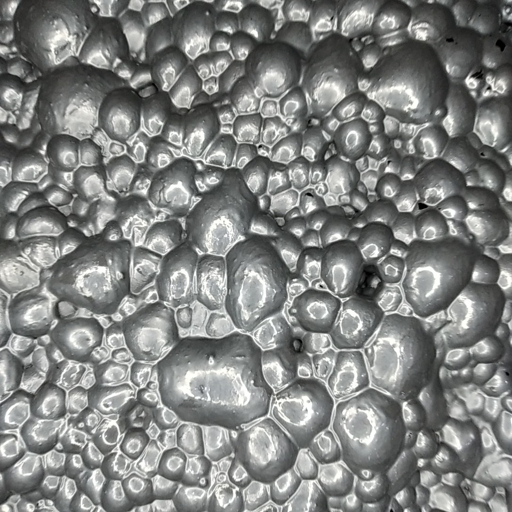

In [5]:
prefix = "frame"
datapath = "./rl4_pb8-7/"

id_example = 0
rawframes = pims.ImageSequence(os.path.join(datapath, prefix + '*.jpg'))
rawframes[id_example]


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.cuda.get_device_name(device))

Tesla T4


In [7]:
def crop(img):
    """
    Crop the image to select the region of interest
    """
    x_min = 45
    x_max = -35
    y_min = 100
    y_max = -300
    return img[y_min:y_max,x_min:x_max]


In [8]:
!pip install --upgrade imutils

  Preparing metadata (setup.py) ... done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25858 sha256=68a765a9c1988ae12cbdbed41db2731d30ccf74d29741d39340a78bd9a650de2
  Stored in directory: /root/.cache/pip/wheels/86/d7/0a/4923351ed1cec5d5e24c1eaf8905567b02a0343b24aa873df2
Successfully built imutils


In [9]:

from imutils import contours
from skimage import measure
import numpy as np
import argparse
import imutils
import cv2


### Here im changing the image to grayscale and then applying median filtering 

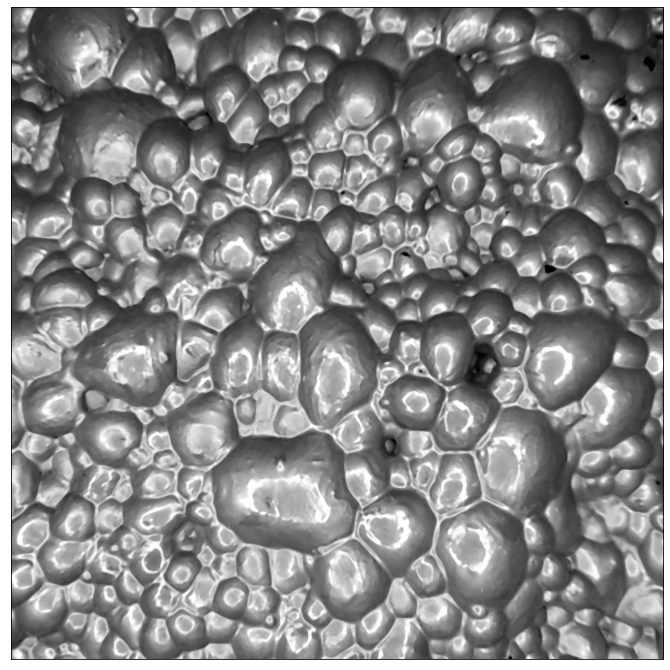

In [17]:
image = rawframes[0]

#transforming the image into gray scale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#applying median filtering blur to eliminate noise if there was any
median = cv2.medianBlur(gray, 5)

plt.imshow(median)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

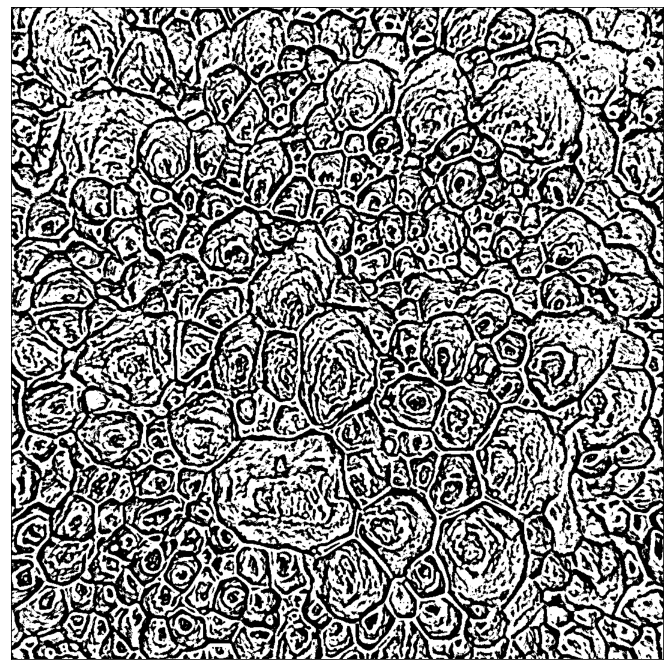

In [52]:
#thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)[1]
thresh = cv2.adaptiveThreshold(median,255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,11,2)
#thresh = cv2.erode(thresh, None, iterations=2)
#thresh = cv2.dilate(thresh, None, iterations=4)
plt.imshow(thresh)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()



In [35]:
# perform a connected component analysis on the thresholded
# image, then initialize a mask to store only the "large"
# components
labels = measure.label(thresh, connectivity=None, background=0)
mask = np.zeros(thresh.shape, dtype="uint8")
# loop over the unique components
for label in np.unique(labels):
	# if this is the background label, ignore it
	if label == 0:
		continue
	# otherwise, construct the label mask and count the
	# number of pixels 
	labelMask = np.zeros(thresh.shape, dtype="uint8")
	labelMask[labels == label] = 255
	numPixels = cv2.countNonZero(labelMask)
	# if the number of pixels in the component is sufficiently
	# large, then add it to our mask of "large blobs"
	if numPixels > 300:
		mask = cv2.add(mask, labelMask)

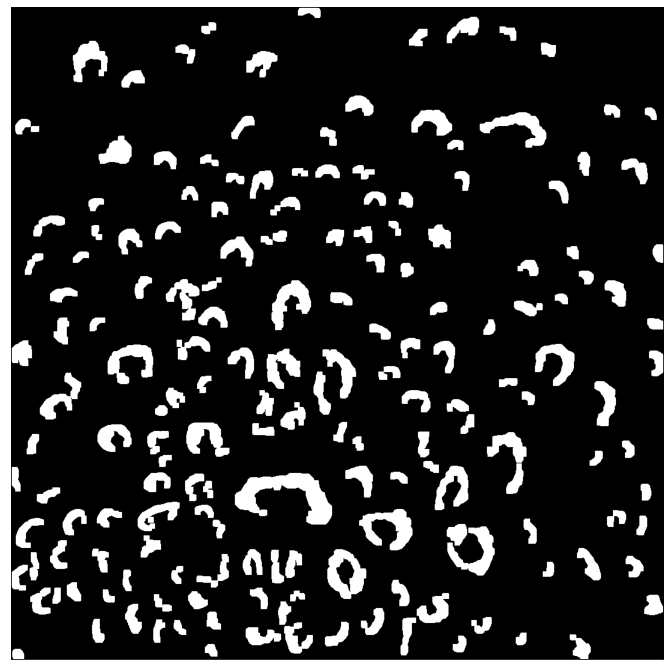

In [36]:
plt.imshow(mask)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


In [37]:
# find the contours in the mask, then sort them from left to
# right
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
cnts = contours.sort_contours(cnts)[0]
# loop over the contours
for (i, c) in enumerate(cnts):
	# draw the bright spot on the image
	(x, y, w, h) = cv2.boundingRect(c)
	((cX, cY), radius) = cv2.minEnclosingCircle(c)
	cv2.circle(image, (int(cX), int(cY)), int(radius),
		(0, 0, 255), 3)
	cv2.putText(image, "#{}".format(i + 1), (x, y - 15),
		cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)
# show the output image


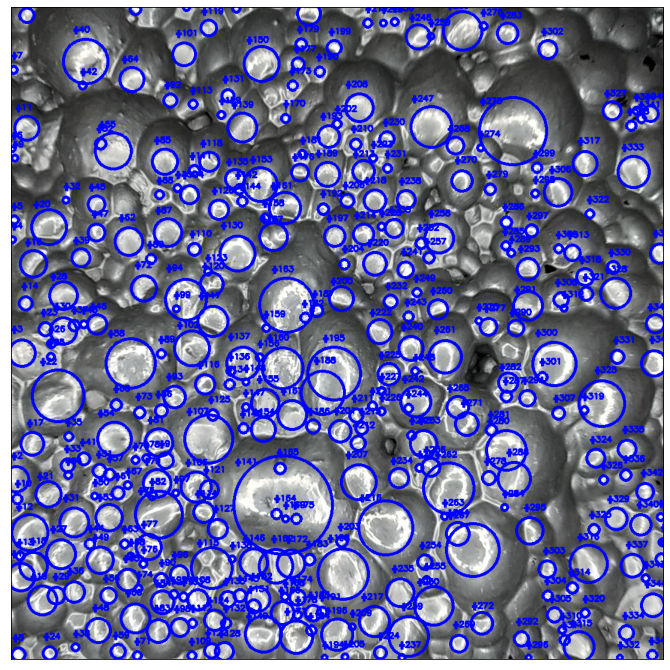

In [38]:
plt.imshow(image)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()
